# S7 - Machine Vision with Python 

------

Machine vision refers to the idea that you can use your computer (ie. Python) to "see". In reality, this just means working with image or video data. I will focus on images, since video is just a collection of images. This is a very broad domain, and so I will focus on two specific areas: 

*   Analyzing Facial Images
*   Analyzing Object Images

I selected these two becuase I believe they are the most common cases of machine vision that you might encounter. I'm also trying to find somewhat "fun" examples, and puting a priority on that over business relevance (as many actual business applications can be quite dull). If you have a specific topic you find interesting, please let me know. 

In [79]:
# Let's load the drive just so that we can use images # 

from google.colab import drive        

In [80]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## S7.A - Handwritten Digit Recognition
--- 

As an introduction to working with image data, I will work through the example fo doing handwriten digit recognition. If you have an iPad / Surface tablet then you have seen where you write with your pen and it converts to text. What I demonstrate below is an example of this technology. 

For this, we will use a very simple example, with a pre-defined dataset. The idea here is to demonstrate how python works with image data and the intuition behind now this is done. 

In [81]:
# Load basic packages # 

import os 
import matplotlib.pyplot as plt 

# Load Image Processing Packages #
import cv2
from google.colab.patches import cv2_imshow

In [82]:
# Now, we load the handwritten digit data from Sklearn

# SKLearn Documentation:  https://scikit-learn.org/stable/auto_examples/datasets/plot_digits_last_image.html#sphx-glr-auto-examples-datasets-plot-digits-last-image-py
# The origin of this data : https://archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits

# It is built into the sklearn package, so we can just download it as follows. 

from sklearn import datasets

digits = datasets.load_digits()

In [83]:
# Extract the Image Files #

Images = digits.images


In [84]:
# Extract the actual values (tags) #

Actual_Values = digits.target

Below, I just want to show you how python sees an image, and then now it is presented to you. 

In [85]:
# I just select one image as a sample image #
SampleImage = Images[0]

In [86]:
# How Python Sees This Image #

SampleImage

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

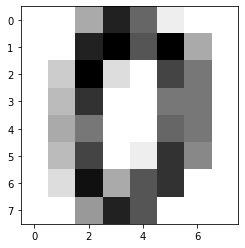

In [11]:
# What is the actual image (How you would see it)

plt.imshow(SampleImage, cmap=plt.cm.gray_r )

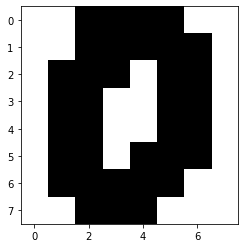

In [12]:
# To make this a bit sharper to read, we convert anything that is slightly grey to black #

import numpy as np 

Temp = np.where(SampleImage>0, 10, SampleImage)

plt.imshow(Temp, cmap=plt.cm.gray_r )

What am I trying to show you here. 

*   Python sees this image as a 8X8 Matrix with a numerical value representing the density (how dark each field should be). 
*   You see a 8X8 pixel image where each pixel (dot) is in some shade of grey. 

In this numerical format, we can work with the data as we would any other prediction problem. 

### S7.A.1 - Classifying Handwritten Digits using "Simple" Methods
--- 

Remember that we have actual values that people have written down indicating what each of these handwritten digits represents. We will use these to "train" the dataset. 

We will now treat this as a statistical problem with the numerical representation of the values as **X** variables, and the hand coded values as **Y** values. 

In [13]:
# We need to convert from this 8X8 format, to a 1X64 format, as with any normal regression. 

X_Values = Images.reshape((len(Images), -1)) 


In [14]:
# Let's fit a model. We use a SVM because we have multiple outcome values and data that clusters naturally -- Radial Base Function is the default kernel # 

from sklearn import svm

clf = svm.SVC(gamma=0.001)

model = clf.fit( X_Values, Actual_Values)


Predicted Value: 0


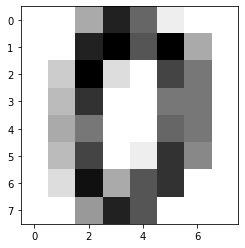

Predicted Value: 1


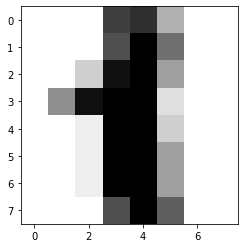

In [15]:
# We can then classify new observations. I will just use the training data here as an illustration # 

PredictedValues = model.predict(X_Values[0:2])

print("Predicted Value: " +  str(PredictedValues[0]))
plt.imshow(Images[0], cmap=plt.cm.gray_r )
plt.show()
print("Predicted Value: " + str(PredictedValues[1]))
plt.imshow(Images[1], cmap=plt.cm.gray_r )
plt.show()

In [16]:
# We can do this in a more disciplined way with a holdout sample and out of sample prediction # 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_Values, Actual_Values, test_size=0.5, shuffle=False)

model = clf.fit(X_train, y_train)

y_predicted = model.predict(X_test)


In [17]:
# To see the classification accuracy # 

from sklearn.metrics import classification_report 

print(classification_report(y_test, y_predicted))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899



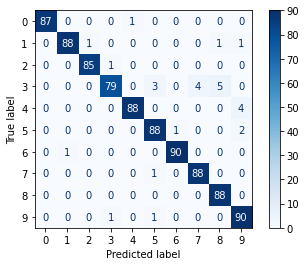

In [18]:
# To see the confusion matrix # 

from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(model, X_test, y_test, cmap = 'Blues')
plt.show()

### S7.A.2 - Classifying Handwritten Digits using "Deep" Methods
--- 

Above, we use common statiastical methods such as regression or SVM. Here, I will show you how this can be done with "deep" methods using neural networks. 

Below, I will show you how this can be done as an illustration of the neural networks methods as these are often prefered for images. 



In [19]:
# We will use the Keras package which is a very easy to use method to develop a neural network 

# This is the type of neural network model.
from keras.models import Sequential

# These are different types of model layers # 
from keras.layers.core import Dense, Activation, Dropout

# ? 
from keras.utils import np_utils

In [20]:
# Keras does not take the same inputs as Sklearn. We have to convert the inputs into a format that keras understands. #

trainData = X_train.reshape( len(X_train), 64)
testData = X_test.reshape( len(X_test), 64)
trainData = trainData.astype("float32")
testData = testData.astype("float32")


In [21]:
# We also have to convert the output into dummies (1/0) for each of the outcomes. 

Train_Labels = np_utils.to_categorical(y_train, 10)
Test_Labels = np_utils.to_categorical(y_test, 10)

In [22]:
# Define the Model #############################################################

Shape_of_Input_Data = (64,)

Num_Output_Classes = 10

# create the model
model = Sequential()

model.add(Dense(512, input_shape= Shape_of_Input_Data))
model.add(Activation("relu"))
model.add(Dropout(0.2))
model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.2))

model.add(Dense(Num_Output_Classes))

model.add(Activation("softmax"))

# summarize the model
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               33280     
_________________________________________________________________
activation (Activation)      (None, 512)               0         
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
activation_1 (Activation)    (None, 256)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                2

In [23]:
# compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# fit the model
history = model.fit(trainData, Train_Labels, validation_data=(testData, Test_Labels), batch_size=50, epochs=10, verbose = True)


Epoch 1/10
18/18 [==============================] - 4s 28ms/step - loss: 3.7883 - accuracy: 0.3064 - val_loss: 0.4314 - val_accuracy: 0.8643
Epoch 2/10
18/18 [==============================] - 0s 6ms/step - loss: 0.4562 - accuracy: 0.8524 - val_loss: 0.2875 - val_accuracy: 0.9177
Epoch 3/10
18/18 [==============================] - 0s 6ms/step - loss: 0.1936 - accuracy: 0.9455 - val_loss: 0.2393 - val_accuracy: 0.9266
Epoch 4/10
18/18 [==============================] - 0s 6ms/step - loss: 0.1570 - accuracy: 0.9440 - val_loss: 0.2403 - val_accuracy: 0.9244
Epoch 5/10
18/18 [==============================] - 0s 6ms/step - loss: 0.1152 - accuracy: 0.9696 - val_loss: 0.1924 - val_accuracy: 0.9444
Epoch 6/10
18/18 [==============================] - 0s 6ms/step - loss: 0.0775 - accuracy: 0.9735 - val_loss: 0.2410 - val_accuracy: 0.9355
Epoch 7/10
18/18 [==============================] - 0s 6ms/step - loss: 0.0561 - accuracy: 0.9817 - val_loss: 0.1776 - val_accuracy: 0.9455
Epoch 8/10
18/18 [=

What is happening above? 

The algorithim is taking a small part of the data (50 observations == batch_size) and passign them through the neural network, then going back and updating the model parameters. At the end of this process, the algorithim goes back again, compares against the holdout data and updates the parameters. This is repeated 10 times (n epochs).  

You get several different types of output (loss, which is a measure of the error) or accuracy which is the share of values accuratley classified. The model reports the accuracy on the training data (accuracy) and on the validation or holdout data (val_accuracy). 

In [24]:
# We can again extract predictions # 

predicted_values = model.predict( testData[0:2])

predicted_values = np.where(predicted_values < 0.3, 0, 1)

predicted_values

array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

In [25]:
# And Compare them to the test data # 

Test_Labels[0:2]

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]], dtype=float32)

#### **Key Takeaways:** 

*   Image Data is effectively numerical data
*   Once converted in numerical form, you can apply various statistical models to classify and identify objects. 

Why was this process above so easy? Because the data we recieved had neatly coded and classified observations. What happens "in the wild" where we might not have a focused breakdown of each image. In the following section, I show you how that can be done easily. 



# S7.B - Working With Facial Image Data (Identifying Faces)
----

As a first step, I will show you how we are going to load image data into python. We are going to use cv2 (https://github.com/opencv/opencv-python) a very powerful, but somwhat cryptic open machine vision package. The documentation is not as clean as pandas or seaborn, so if you want to change something, you often have to rely on Google. 


In [87]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [88]:
import os 

os.chdir("/content/drive/MyDrive/Teaching/DSO 574/Notebooks for Python Workshops")

In [89]:
image = cv2.imread("./Image Files/N Cage Photos/Cage1.jpeg")

In [90]:
# How python sees the photo # 

image[0]

array([[ 3, 11, 58],
       [ 3, 11, 58],
       [ 3, 11, 58],
       ...,
       [49, 44, 43],
       [51, 48, 50],
       [47, 48, 52]], dtype=uint8)

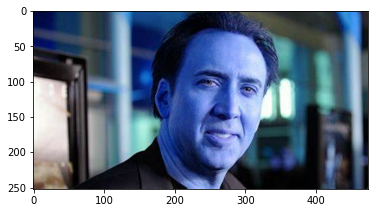

In [91]:
# Let's just tell python (using matplotlib) to display the photo for us # 

plt.imshow(image)

This discoloration occurs because of how programming languages such as python interpret the numerical values that represent the photo. We can clean this up by asking python to convert this into a RGB format (red, green, blue). 

Just a quick physics reminder. All colors can be made up of Red, Green, Blue. Therefore the color of any pixel (dot) can be represented by the ammount of Red, Green, or Blue in that pixel. Later, we will specify that explcitly for python. e.g. Red = (255,0,0), Blue = (0,0,255), Black = (255,255,255), White = (0,0,0).

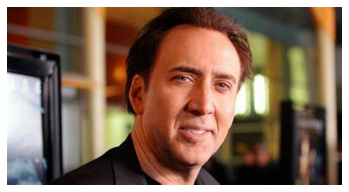

In [92]:
# Lets make the photo in its normal color # 

color_photo = cv2.cvtColor(image, cv2.cv2.COLOR_BGR2RGB)

plt.axis('off')
plt.imshow(color_photo)
plt.show()

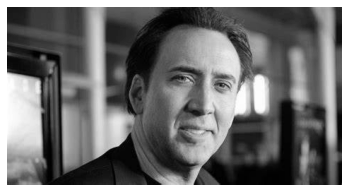

In [93]:
# We can also do this in Grayscale # 

gray_photo = cv2.cvtColor(image, cv2.cv2.COLOR_BGR2GRAY)

plt.axis('off')
plt.imshow(gray_photo, cmap=plt.cm.gray)
plt.show()

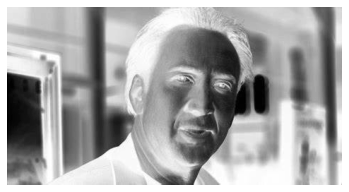

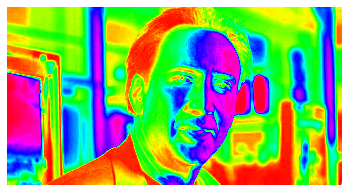

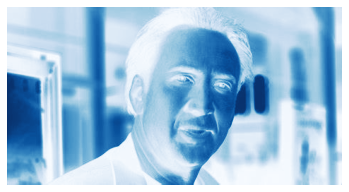

In [94]:
# We can also change the colormap (colors show) and make your own filters # 

gray_photo = cv2.cvtColor(image, cv2.cv2.COLOR_BGR2GRAY)

plt.axis('off')
plt.imshow(gray_photo, cmap=plt.cm.binary)
plt.show()

plt.axis('off')
plt.imshow(gray_photo, cmap=plt.cm.hsv)
plt.show()


plt.axis('off')
plt.imshow(gray_photo, cmap=plt.cm.Blues)
plt.show()



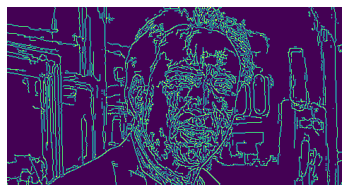

In [95]:
# You can also identify edges # 

egdes = cv2.Canny(image, 30, 100)

plt.axis('off')
plt.imshow(egdes)
plt.show()



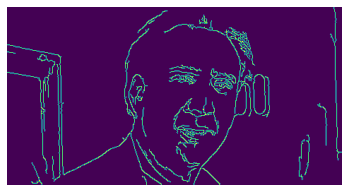

In [96]:
# Changing the parameters can allow you to focus on the different parts of the image. #

# High threshold to focus on big (high contrast) lines #

egdes = cv2.Canny(image, 100, 300)

plt.axis('off')
plt.imshow(egdes)
plt.show()


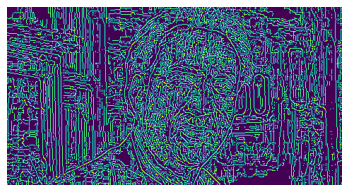

In [97]:
# Low threshold to identify any possible lines # 

egdes = cv2.Canny(image, 1, 20)

plt.axis('off')
plt.imshow(egdes)
plt.show()

This was all meant to show you how python can work with the numerical data (that represents an image) and alter the output in very simple ways to create different outcomes. This is often the technology behind very simple filters that you see in things like Instagram. 

In terms of "useful" applications, this is important because it shows you how to read in the data, and how to convert the output. For next steps, we will look at how to work with this data. 

## S7.B.1 - Face Detection & Processing
------

Often, we want to know about the face (who the person is, their emotion, etc.) and not the surrounding objects (ie. Door behind N. Cage).

The idea behind this is quite simple, we go through different parts of the image and run a prediction algorithim which identifies if that is a face. We then select the locations most likely to contain a face. 

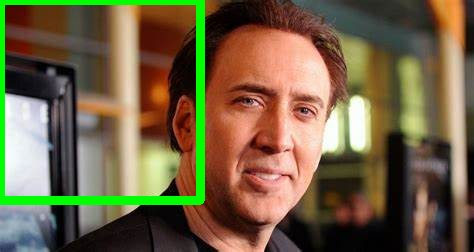

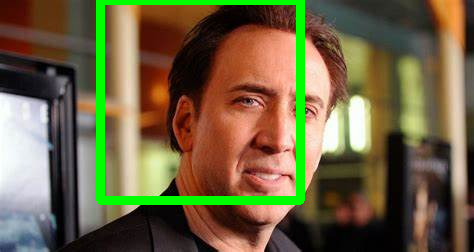

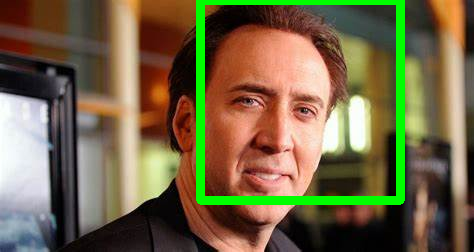

In [98]:
# We are going to basically create a moving window (in green) and move it throughout the figure # 

ws = (200,200)
step = 100

for y in range(0, image.shape[0] - ws[1],step):
  for x in range(0,image.shape[1] - ws[0], step):
    
    copy = image.copy()
    
    cv2.rectangle(copy, (x, y), (x + ws[0], y + ws[1]), (0,255,0), 7)
    cv2_imshow(copy)
    

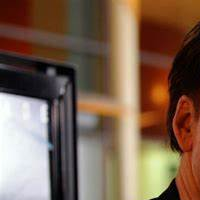

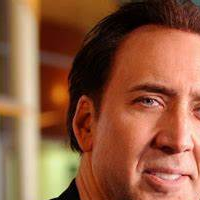

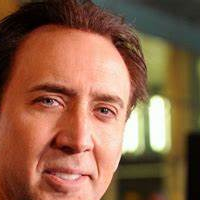

In [99]:
# We can select the individual images # 

ws = (200,200)
step = 100

for y in range(0, image.shape[0] - ws[1],step):
  for x in range(0,image.shape[1] - ws[0], step):
    
    copy = image.copy()
    temp = copy[y:y+ws[1],x:x+ws[0]]
    cv2_imshow(temp)

Next, we are going to feed each of these images to a classification algorithim in order to identify whether there is something contained in these images. 

We are going to load a pre trained algorithim that already exists in the keras / tensorflow package [https://keras.io/api/applications/]. Ours is going to be the RestNet50 [Deep Residual Learning for Image Recognition] and you can see the coresponding paper here: https://arxiv.org/abs/1512.03385. Also, I should note that this algorithim is based on the imagenet data: http://image-net.org/



In [100]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications import imagenet_utils
import numpy as np

In [101]:
# Now let's feed this through an image classification model to identify which is a face # 

model = ResNet50(weights="imagenet", include_top=True)

ws = (200,200)
step = 100

boxes = []

for y in range(0, image.shape[0] - ws[1],step):
  for x in range(0,image.shape[1] - ws[0], step):
    
    copy = image.copy()
    box = copy[y:y+ws[1],x:x+ws[0]]
    
    INPUT_SIZE = (224, 224)
    box = cv2.resize(box, INPUT_SIZE)
    box = img_to_array(box)
    box = preprocess_input(box)

    box = np.array([box], dtype="float32")

    predictions = model.predict(box)
    predictions = imagenet_utils.decode_predictions(predictions, top=1)

    print(predictions)

[[('n04404412', 'television', 0.47930476)]]
[[('n02883205', 'bow_tie', 0.16965115)]]
[[('n02883205', 'bow_tie', 0.1758559)]]


It's not doing a great job, why? What could we do differently? 

*   Windowing (selecting different windows, finding a more creative way of defining bounding boxes. 
*   Model is not trained to identify only faces / non-faces. 
*   Different classifier
*   Different preprocessing

Rather than fix this ourselves, we will use annother algorithim that is pre-made for this purpose. 

## S7.B.2 Using a Pre-Existing "Face Identification" Package
----

In [105]:
# These are machine vision tools that make some of the stuff above easier # 

from imutils import face_utils
import dlib

As a sidenote, it is perhaps useful for you to know that dlib is written in c++ rather than python. One of the things that is nice about a language like python, is that there are packages from other languages that have been "ported" to python so you can use them easily without you having to switch programming languages. 

In [106]:
# Load the "Frontal Face Detector" Tool

detector = dlib.get_frontal_face_detector()

In [107]:
# Find the Faces in the Image # 

faces = detector.run(image, 1, -1)

In [108]:
# To see the output. It gives us the location of the boxes and then the likelihood that it is a face # 
faces

(rectangles[[(210, 67) (339, 196)], [(268, 82) (397, 211)], [(225, 126) (315, 216)]],
 [0.84514886517657, -0.5757691226469164, -0.9813009202853249],
 [0, 0, 4])

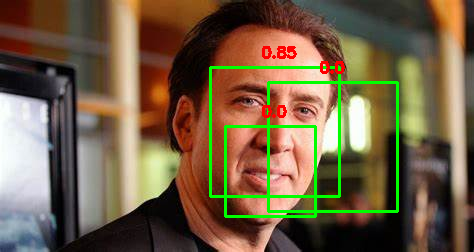

In [109]:
# To Show this Visually, we can see the boxes in green, and then the likelihood of it being a face in red. 

image2 = image.copy()

for i in list(zip(list(faces[0]), list(faces[1]))):
    
    rect = i[0]
    
    (x, y, w, h) = face_utils.rect_to_bb(rect)
    cv2.rectangle(image2, (x, y), (x + w, y + h), (0, 255, 0), 2)

for i in list(zip(list(faces[0]), list(faces[1]))):

    rect = i[0]
    
    (x, y, w, h) = face_utils.rect_to_bb(rect)
    
    score = np.round(i[1], 2)
    
    if score < 0: 
        score = 0.00
    
    # show the face number
    cv2.putText(image2, str(score), (x + int(w/2.5), y - 10 ),
    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    
cv2_imshow(image2)

This is really the first step to performing analysis where you use the facial image data. Once you have the face identified, you can run a variety of other algorithims. 


# S7.C - Identifying and Manipulating Face Landmarks
---- 

One very common application which you often see relies on facial landmarks. Facial landmarks are the points that identify the nose, chin, mouth, etc. This is what is used when, for example, Zoom touches up your appearance, or other visual aids. 

You need to download this file, and upload it to the same directory so that you can load it into python. 

In [112]:
# We are going to use something that has already been trained by others => https://github.com/italojs/facial-landmarks-recognition/blob/master/shape_predictor_68_face_landmarks.dat

predictor = dlib.shape_predictor("./shape_predictor_68_face_landmarks.dat")

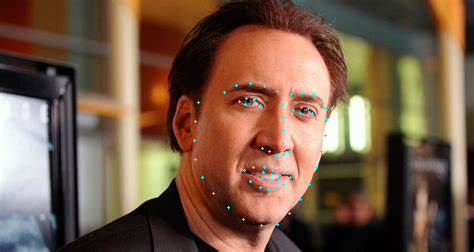

In [113]:
image2 = image.copy()

DotSize = 1
DotColor = (255,255,0)

for i in list(zip(list(faces[0]), list(faces[1]))):
    
    rect = i[0]
    score = np.round(i[1], 2)
    
    if score > 0.7:
    
        shape = predictor(image2, rect)
        shape = face_utils.shape_to_np(shape)
    
        # Draw the Dots #
        for (x, y) in shape:
            cv2.circle(image2, (x, y), DotSize, DotColor, -1)

cv2_imshow(image2)           

In [114]:
# We can select different parts of the face landmarks based on this -- See this link to see the different tags: https://ibug.doc.ic.ac.uk/resources/facial-point-annotations/

Chin = shape[:17]
LeftEyebrow = shape[17:22]
RightEyebrow = shape[22:27]

Lips = shape[48:59]
Mouth = shape[61:68]

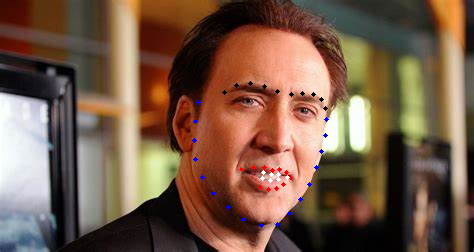

In [115]:
# We can color code this to make sure we have done it correctly # 

image2 = image.copy()

for i in list(zip(list(faces[0]), list(faces[1]))):
    
    rect = i[0]
    score = np.round(i[1], 2)
    
    if score > 0.5:
    
        shape = predictor(image2, rect)
        shape = face_utils.shape_to_np(shape)
  
        
        for (x, y) in Chin:
            cv2.circle(image2, (x, y), 2, (255, 0, 0), -1)
        
        for (x, y) in LeftEyebrow:
            cv2.circle(image2, (x, y), 2, (0, 0, 0), -1)
            
        for (x, y) in RightEyebrow:
            cv2.circle(image2, (x, y), 2, (0, 0, 0), -1) 
            
        for (x, y) in Lips:
            cv2.circle(image2, (x, y), 2, (0, 0, 255), -1) 

        for (x, y) in Mouth:
            cv2.circle(image2, (x, y), 2, (255, 255, 255), -1) 

            
cv2_imshow(image2)       

## S7.C.1 - Manipulating Facial Features based on Landmarks
---


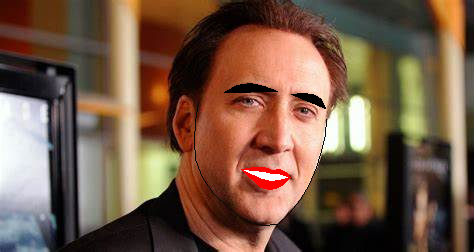

In [116]:
# This is the underlying technology used to apply digital makeup, or modify video images  # 

image2 = image.copy()

for i in list(zip(list(faces[0]), list(faces[1]))):
    
    rect = i[0]
    score = np.round(i[1], 2)
    
    if score > 0.5:
    
        shape = predictor(image2, rect)
        shape = face_utils.shape_to_np(shape)
    
        
        Chin = shape[:17]
        LeftEyebrow = shape[17:22]
        RightEyebrow = shape[22:27]

        Lips = shape[48:59]
        Mouth = shape[60:69]
        
        #for (x, y) in Chin:
        #    cv2.circle(image2, (x, y), 3, (255, 0, 0), -1)
        
        points= np.reshape( Chin.tolist(), (-1, 1, 2))  
        cv2.polylines(image2, [points],0, (10, 10, 10), 1) 

        points= np.reshape( LeftEyebrow.tolist(), (-1, 1, 2))  
        cv2.fillPoly(image2, [points], (0, 0, 0), 8) 
        
        points= np.reshape( RightEyebrow.tolist(), (-1, 1, 2))  
        cv2.fillPoly(image2, [points], (0, 0, 0), 8) 

            
        points= np.reshape( Lips.tolist(), (-1, 1, 2))  
        cv2.fillPoly(image2, [points], (0, 0, 255) , 8) 

        points= np.reshape( Mouth.tolist(), (-1, 1, 2))  
        cv2.fillPoly(image2, [points], (255, 255, 255), 8) 

            

cv2_imshow(image2)          

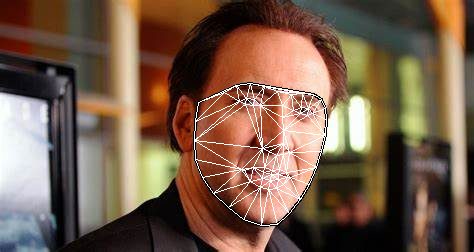

In [117]:
# You can also link these dots in order to manipulate facial structures # 

# Define Initial Packages #################################################

def extract_index_nparray(nparray):
    index = None
    for num in nparray[0]:
        index = num
        break
    return index

def draw_triangles(image2, faces):

  for i in list(zip(list(faces[0]), list(faces[1]))):
      
      rect = i[0]
      score = np.round(i[1], 2)
      
      if score > 0.5:
      
          shape = predictor(image2, rect)
          shape = face_utils.shape_to_np(shape)
      
          points= np.reshape( shape.tolist(), (-1, 1, 2))  

          convexhull = cv2.convexHull(points)
          cv2.polylines(image2, [convexhull], True, (0, 0, 0), 2)
          

          # Construct Tiangles that link the different facial landmarks # 
          rect = cv2.boundingRect(convexhull)
          subdiv = cv2.Subdiv2D(rect)
          subdiv.insert(points)
          triangles = subdiv.getTriangleList()
          triangles = np.array(triangles, dtype=np.int32)

          indexes_triangles = []
          for t in triangles:
              pt1 = (t[0], t[1])
              pt2 = (t[2], t[3])
              pt3 = (t[4], t[5])
              index_pt1 = np.where((points == pt1).all(axis=1))
              index_pt1 = extract_index_nparray(index_pt1)
              index_pt2 = np.where((points == pt2).all(axis=1))
              index_pt2 = extract_index_nparray(index_pt2)
              index_pt3 = np.where((points == pt3).all(axis=1))
              index_pt3 = extract_index_nparray(index_pt3)
              if index_pt1 is not None and index_pt2 is not None and index_pt3 is not None:
                  triangle = [index_pt1, index_pt2, index_pt3]
                  indexes_triangles.append(triangle)
              cv2.line(image2, pt1, pt2, (255, 255, 255), 1)
              cv2.line(image2, pt2, pt3, (255, 255, 255), 1)
              cv2.line(image2, pt1, pt3, (255, 255, 255), 1)
  return image2 

image = cv2.imread("./Image Files/N Cage Photos/Cage1.jpeg")

image2 = image.copy()

images = [image2]

for i in images:

  faces = detector.run(i, 1, -1)

  image2 = draw_triangles(i, faces)

cv2_imshow(image2)          


This is the underlying technology in face swapping, or "deep-fakes", basically swapping the images from one photo to annother. 



## S7.C.2 - Faceswapping (a homebrew version of deepfakes)
---


For a very silly demonstration, I will show you how this can be done with python. I will an image of Nicholas Cage with an image of John Travolta. 

If you are wondering whether this was inspired by the plot of the movie Face-Off, the answer is yes. 

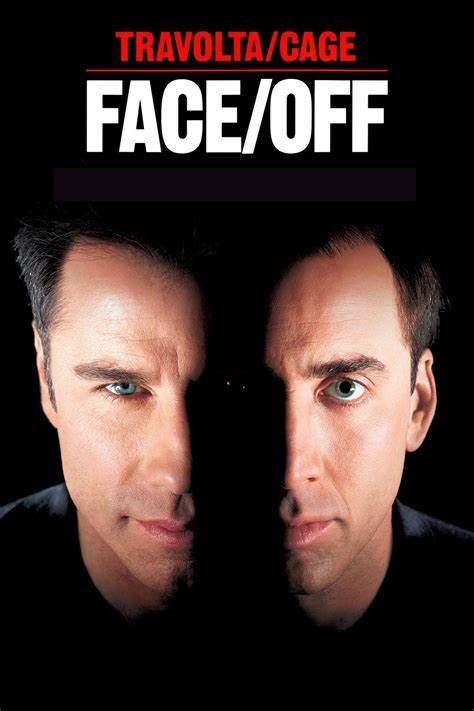

The idea is once you have the images with the face landmarks linked (face triangles), you can swap these and adjust the shape and colors. 




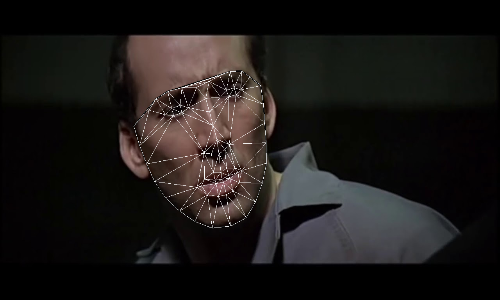

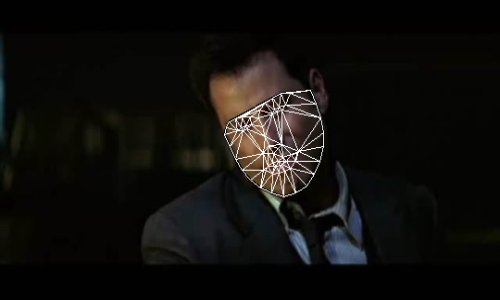

In [118]:
img = cv2.imread("./Image Files/CageFaceOff1.jpg")
img2 = cv2.imread("./Image Files/TravoltaFaceOff3.jpg")

images = [img, img2]

for i in images:

  faces = detector.run(i, 1, -1)

  image2 = draw_triangles(i, faces)

  image2 = cv2.resize(image2, (500,300))

  cv2_imshow(image2)          


I used the code created by this individual, and adapted it to my context. 

https://pysource.com/2019/05/28/face-swapping-explained-in-8-steps-opencv-with-python/

In [119]:


img = cv2.imread("./Image Files/CageFaceOff1.jpg")
img2 = cv2.imread("./Image Files/TravoltaFaceOff3.jpg")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
mask = np.zeros_like(img_gray)

img2_new_face = np.zeros_like(img2)

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
# Face 1
faces = detector(img_gray)
for face in faces:
    landmarks = predictor(img_gray, face)
    landmarks_points = []
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        landmarks_points.append((x, y))

        # cv2.circle(img, (x, y), 3, (0, 0, 255), -1)

    points = np.array(landmarks_points, np.int32)
    convexhull = cv2.convexHull(points)
    # cv2.polylines(img, [convexhull], True, (255, 0, 0), 3)
    cv2.fillConvexPoly(mask, convexhull, 255)

    face_image_1 = cv2.bitwise_and(img, img, mask=mask)

    # Delaunay triangulation
    rect = cv2.boundingRect(convexhull)
    subdiv = cv2.Subdiv2D(rect)
    subdiv.insert(landmarks_points)
    triangles = subdiv.getTriangleList()
    triangles = np.array(triangles, dtype=np.int32)

    indexes_triangles = []
    for t in triangles:
        pt1 = (t[0], t[1])
        pt2 = (t[2], t[3])
        pt3 = (t[4], t[5])

        index_pt1 = np.where((points == pt1).all(axis=1))
        index_pt1 = extract_index_nparray(index_pt1)

        index_pt2 = np.where((points == pt2).all(axis=1))
        index_pt2 = extract_index_nparray(index_pt2)

        index_pt3 = np.where((points == pt3).all(axis=1))
        index_pt3 = extract_index_nparray(index_pt3)

        if index_pt1 is not None and index_pt2 is not None and index_pt3 is not None:
            triangle = [index_pt1, index_pt2, index_pt3]
            indexes_triangles.append(triangle)




# Face 2
faces2 = detector(img2_gray)
for face in faces2:
	landmarks = predictor(img2_gray, face)
	landmarks_points2 = []
	for n in range(0, 68):
		x = landmarks.part(n).x
		y = landmarks.part(n).y
		landmarks_points2.append((x, y))

		#cv2.circle(img2, (x, y), 3, (0, 255, 0), -1)
	points2 = np.array(landmarks_points2, np.int32)
	convexhull2 = cv2.convexHull(points2)

# Triangulation of both faces
for triangle_index in indexes_triangles:
	# Triangulation of the first face
	tr1_pt1 = landmarks_points[triangle_index[0]]
	tr1_pt2 = landmarks_points[triangle_index[1]]
	tr1_pt3 = landmarks_points[triangle_index[2]]
	triangle1 = np.array([tr1_pt1, tr1_pt2, tr1_pt3], np.int32)

	rect1 = cv2.boundingRect(triangle1)
	(x, y, w, h) = rect1
	cropped_triangle = img[y: y + h, x: x + w]
	cropped_tr1_mask = np.zeros((h, w), np.uint8)

	points = np.array([[tr1_pt1[0] - x, tr1_pt1[1] - y],
					  [tr1_pt2[0] - x, tr1_pt2[1] - y],
					  [tr1_pt3[0] - x, tr1_pt3[1] - y]], np.int32)

	cv2.fillConvexPoly(cropped_tr1_mask, points, 255)
	cropped_triangle = cv2.bitwise_and(cropped_triangle, cropped_triangle,
									   mask=cropped_tr1_mask)


	# cv2.line(img, tr1_pt1, tr1_pt2, (0, 0, 255), 2)
	# cv2.line(img, tr1_pt3, tr1_pt2, (0, 0, 255), 2)
	# cv2.line(img, tr1_pt1, tr1_pt3, (0, 0, 255), 2)

	# Triangulation of second face
	tr2_pt1 = landmarks_points2[triangle_index[0]]
	tr2_pt2 = landmarks_points2[triangle_index[1]]
	tr2_pt3 = landmarks_points2[triangle_index[2]]
	triangle2 = np.array([tr2_pt1, tr2_pt2, tr2_pt3], np.int32)

	rect2 = cv2.boundingRect(triangle2)
	(x, y, w, h) = rect2
	cropped_triangle2 = img2[y: y + h, x: x + w]
	cropped_tr2_mask = np.zeros((h, w), np.uint8)

	points2 = np.array([[tr2_pt1[0] - x, tr2_pt1[1] - y],
					   [tr2_pt2[0] - x, tr2_pt2[1] - y],
					   [tr2_pt3[0] - x, tr2_pt3[1] - y]], np.int32)

	cv2.fillConvexPoly(cropped_tr2_mask, points2, 255)
	cropped_triangle2 = cv2.bitwise_and(cropped_triangle2, cropped_triangle2,
									   mask=cropped_tr2_mask)

	# cv2.line(img2, tr2_pt1, tr2_pt2, (0, 0, 255), 2)
	# cv2.line(img2, tr2_pt3, tr2_pt2, (0, 0, 255), 2)
	# cv2.line(img2, tr2_pt1, tr2_pt3, (0, 0, 255), 2)

	# Warp triangles
	points = np.float32(points)
	points2 = np.float32(points2)
	M = cv2.getAffineTransform(points, points2)
	warped_triangle = cv2.warpAffine(cropped_triangle, M, (w, h))
	
	# Reconstructing destination face
	img2_new_face_rect_area = img2_new_face[y: y + h, x: x + w]
	img2_new_face_rect_area = cv2.add(img2_new_face_rect_area, warped_triangle)
	img2_new_face[y: y + h, x: x + w] = img2_new_face_rect_area

# Face swapped (putting 1st face into 2nd face)
img2_face_mask = np.zeros_like(img2_gray)
img2_head_mask = cv2.fillConvexPoly(img2_face_mask, convexhull2, 255)
img2_face_mask = cv2.bitwise_not(img2_head_mask)

img2_head_noface = np.zeros_like(img)

img2_head_noface = cv2.bitwise_and(img2, img2, mask=img2_face_mask)
result = cv2.add(img2_head_noface, img2_new_face)



Image 1


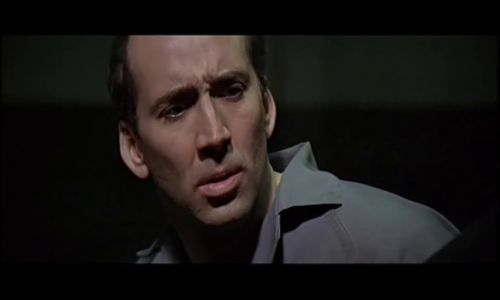

Image 2


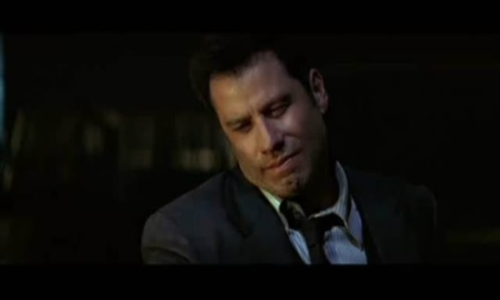

Combined


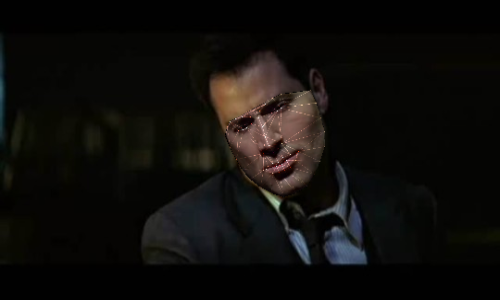

In [120]:
print("Image 1")
cv2_imshow( cv2.resize(img, (500, 300)))

print("Image 2")
cv2_imshow( cv2.resize(img2, (500, 300)))

print("Combined")
cv2_imshow( cv2.resize(result, (500, 300)))

In [121]:
img = cv2.imread("./Image Files/CageFaceOff1.jpg")
img2 = cv2.imread("./Image Files/TravoltaFaceOff3.jpg")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
mask = np.zeros_like(img_gray)


detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
height, width, channels = img2.shape
img2_new_face = np.zeros((height, width, channels), np.uint8)




# Face 1
faces = detector(img_gray)
for face in faces:
    landmarks = predictor(img_gray, face)
    landmarks_points = []
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        landmarks_points.append((x, y))



    points = np.array(landmarks_points, np.int32)
    convexhull = cv2.convexHull(points)
    # cv2.polylines(img, [convexhull], True, (255, 0, 0), 3)
    cv2.fillConvexPoly(mask, convexhull, 255)

    face_image_1 = cv2.bitwise_and(img, img, mask=mask)

    # Delaunay triangulation
    rect = cv2.boundingRect(convexhull)
    subdiv = cv2.Subdiv2D(rect)
    subdiv.insert(landmarks_points)
    triangles = subdiv.getTriangleList()
    triangles = np.array(triangles, dtype=np.int32)

    indexes_triangles = []
    for t in triangles:
        pt1 = (t[0], t[1])
        pt2 = (t[2], t[3])
        pt3 = (t[4], t[5])


        index_pt1 = np.where((points == pt1).all(axis=1))
        index_pt1 = extract_index_nparray(index_pt1)

        index_pt2 = np.where((points == pt2).all(axis=1))
        index_pt2 = extract_index_nparray(index_pt2)

        index_pt3 = np.where((points == pt3).all(axis=1))
        index_pt3 = extract_index_nparray(index_pt3)

        if index_pt1 is not None and index_pt2 is not None and index_pt3 is not None:
            triangle = [index_pt1, index_pt2, index_pt3]
            indexes_triangles.append(triangle)



# Face 2
faces2 = detector(img2_gray)
for face in faces2:
    landmarks = predictor(img2_gray, face)
    landmarks_points2 = []
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        landmarks_points2.append((x, y))


    points2 = np.array(landmarks_points2, np.int32)
    convexhull2 = cv2.convexHull(points2)

lines_space_mask = np.zeros_like(img_gray)
lines_space_new_face = np.zeros_like(img2)
# Triangulation of both faces
for triangle_index in indexes_triangles:
    # Triangulation of the first face
    tr1_pt1 = landmarks_points[triangle_index[0]]
    tr1_pt2 = landmarks_points[triangle_index[1]]
    tr1_pt3 = landmarks_points[triangle_index[2]]
    triangle1 = np.array([tr1_pt1, tr1_pt2, tr1_pt3], np.int32)


    rect1 = cv2.boundingRect(triangle1)
    (x, y, w, h) = rect1
    cropped_triangle = img[y: y + h, x: x + w]
    cropped_tr1_mask = np.zeros((h, w), np.uint8)


    points = np.array([[tr1_pt1[0] - x, tr1_pt1[1] - y],
                       [tr1_pt2[0] - x, tr1_pt2[1] - y],
                       [tr1_pt3[0] - x, tr1_pt3[1] - y]], np.int32)

    cv2.fillConvexPoly(cropped_tr1_mask, points, 255)

    # Lines space
    cv2.line(lines_space_mask, tr1_pt1, tr1_pt2, 255)
    cv2.line(lines_space_mask, tr1_pt2, tr1_pt3, 255)
    cv2.line(lines_space_mask, tr1_pt1, tr1_pt3, 255)
    lines_space = cv2.bitwise_and(img, img, mask=lines_space_mask)

    # Triangulation of second face
    tr2_pt1 = landmarks_points2[triangle_index[0]]
    tr2_pt2 = landmarks_points2[triangle_index[1]]
    tr2_pt3 = landmarks_points2[triangle_index[2]]
    triangle2 = np.array([tr2_pt1, tr2_pt2, tr2_pt3], np.int32)


    rect2 = cv2.boundingRect(triangle2)
    (x, y, w, h) = rect2

    cropped_tr2_mask = np.zeros((h, w), np.uint8)

    points2 = np.array([[tr2_pt1[0] - x, tr2_pt1[1] - y],
                        [tr2_pt2[0] - x, tr2_pt2[1] - y],
                        [tr2_pt3[0] - x, tr2_pt3[1] - y]], np.int32)

    cv2.fillConvexPoly(cropped_tr2_mask, points2, 255)

    # Warp triangles
    points = np.float32(points)
    points2 = np.float32(points2)
    M = cv2.getAffineTransform(points, points2)
    warped_triangle = cv2.warpAffine(cropped_triangle, M, (w, h))
    warped_triangle = cv2.bitwise_and(warped_triangle, warped_triangle, mask=cropped_tr2_mask)

    # Reconstructing destination face
    img2_new_face_rect_area = img2_new_face[y: y + h, x: x + w]
    img2_new_face_rect_area_gray = cv2.cvtColor(img2_new_face_rect_area, cv2.COLOR_BGR2GRAY)
    _, mask_triangles_designed = cv2.threshold(img2_new_face_rect_area_gray, 1, 255, cv2.THRESH_BINARY_INV)
    warped_triangle = cv2.bitwise_and(warped_triangle, warped_triangle, mask=mask_triangles_designed)

    img2_new_face_rect_area = cv2.add(img2_new_face_rect_area, warped_triangle)
    img2_new_face[y: y + h, x: x + w] = img2_new_face_rect_area



# Face swapped (putting 1st face into 2nd face)
img2_face_mask = np.zeros_like(img2_gray)
img2_head_mask = cv2.fillConvexPoly(img2_face_mask, convexhull2, 255)
img2_face_mask = cv2.bitwise_not(img2_head_mask)


img2_head_noface = cv2.bitwise_and(img2, img2, mask=img2_face_mask)
result = cv2.add(img2_head_noface, img2_new_face)

(x, y, w, h) = cv2.boundingRect(convexhull2)
center_face2 = (int((x + x + w) / 2), int((y + y + h) / 2))

seamlessclone = cv2.seamlessClone(result, img2, img2_head_mask, center_face2, cv2.NORMAL_CLONE)


Image 1


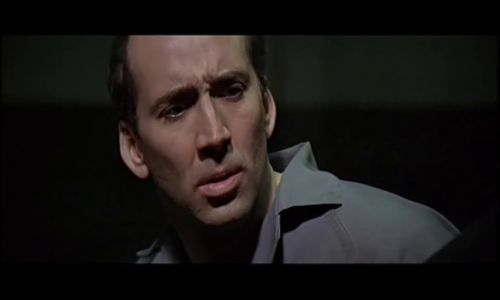

Image 2


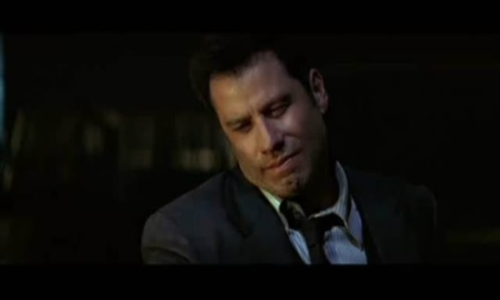

Combined


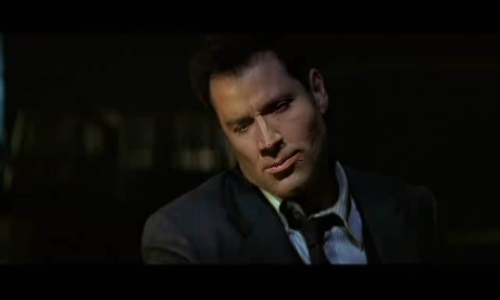

In [122]:
print("Image 1")
cv2_imshow( cv2.resize(img, (500, 300)))

print("Image 2")
cv2_imshow( cv2.resize(img2, (500, 300)))

print("Combined")
cv2_imshow( cv2.resize(seamlessclone, (500, 300)))

## S7.C.3 - Facial Similarity
---

You can use the same technology to identify whether pictures are of the same person, or of different people. 

In [123]:
!pip install face_recognition


In [124]:
import face_recognition

In [125]:
# We Convert the Images into a numerical value (encoding) #

cage_encoding = face_recognition.face_encodings(img)[0]
travolta_encoding = face_recognition.face_encodings(img2)[0]
faceoff_encoding = face_recognition.face_encodings(seamlessclone)[0]

We can now comare the various images

In [130]:
# Cage to Travolta #

face_recognition.compare_faces([cage_encoding], travolta_encoding)

[False]

In [132]:
# Cage to "Fake Travolta"

face_recognition.compare_faces([cage_encoding], faceoff_encoding)

[True]

In [131]:
# Cage to "Fake Travolta"

face_recognition.compare_faces([travolta_encoding], faceoff_encoding)

[False]

In [133]:
from sklearn.metrics.pairwise import cosine_distances

cosine_distances( [travolta_encoding, faceoff_encoding, cage_encoding] )

array([[0.        , 0.09091191, 0.14482465],
       [0.09091191, 0.        , 0.05155921],
       [0.14482465, 0.05155921, 0.        ]])

In [134]:
#CageBaseline = cv2.imread("./Image Files/Cage1.jpeg")

#cage_encoding = face_recognition.face_encodings(CageBaseline)[0]

files = os.listdir("./Image Files/N Cage Photos")


for file in files: 

  img = cv2.imread("./Image Files/N Cage Photos/" + file)

  #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  image_encoding = face_recognition.face_encodings(img)[0]

  Test = face_recognition.compare_faces([cage_encoding], image_encoding)

  if Test == True: 
    
    print("Yes it is Nic Cage")

  else: 

    print("No. It is not Nic Cage")


  cv2_imshow(img)

Output hidden; open in https://colab.research.google.com to view.

In [78]:
cv2_imshow(CageBaseline)

AttributeError: ignored